## Inner filter model

We will use the two models for the observed fluorescence. First, the "power law" model:

$$
f = (a[S]^{b} - c)[P] + d[S] + e
$$

Here, $f$ is the observed fluorescence, $P$ is the product (assumed to be equivalent to EDANS), $S$ is the substrate, and $a$, $b$, $c$, ... are constants. This model assumes:

- the background has been subtracted!
- the product and EDANS have the same fluorescence per molecule
- the substrate fluorescence is linear in concentration and NOT affected by the presence of product
- the product fluo is linear in concentration
- the inner filter effect ie the reduction in product fluorescence as a function of background substrate, is a power law

Second, the "independent linear model":

$$
f = a([S]) * [P] + b([S])
$$

Where $a$ and $b$ are constants fit for each concentration of substrate $[S]$. This model has more parameters and is more flexible, as $a$/$b$ are arbitrary functions of $[S]$.

In [17]:
import numpy as np
from matplotlib import pyplot as plt

from scipy import optimize

In [18]:
def load_calib(filename, cols=np.arange(12), blank=[7,11]):
    cols = np.array(cols)
    x = np.genfromtxt(filename, delimiter=',').reshape(4,8,12)
    x = x.mean(0)
    x = x[:,cols] - x[blank[0], blank[1]]
    return x

In [19]:
nom_S_concs = [640.0 / (2 ** i) for i in range(8)]
print(nom_S_concs)

P_concs = [0.0, 2.5, 5.0, 7.5, 10.0]
print(P_concs)

[640.0, 320.0, 160.0, 80.0, 40.0, 20.0, 10.0, 5.0]
[0.0, 2.5, 5.0, 7.5, 10.0]


First, use the absorbance spectrum to calibrate for the substrate concentration

$\Theta_{EDANS} = 15100 M^{-1} cm^{-1}$ at 472 nm

(341, 8)


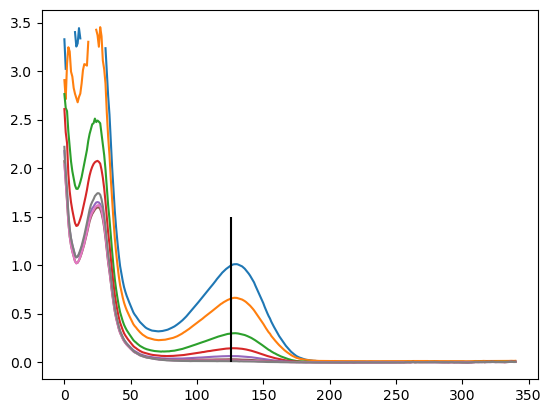

In [20]:
subs_abs = np.genfromtxt('edans/210601_substrate_ABS.csv', delimiter=',').reshape(-1, 8,12)[:,:,0]
subs_abs = subs_abs - subs_abs[-1, -1]
print(subs_abs.shape)

# collected between 220 nm and 900 nm with a 2 nm resolution 

idx_472 = 126
ex_472 = 15100.0

plt.figure()
plt.plot(subs_abs)
plt.vlines(idx_472, 0.0, 1.5, color='k')
plt.show()

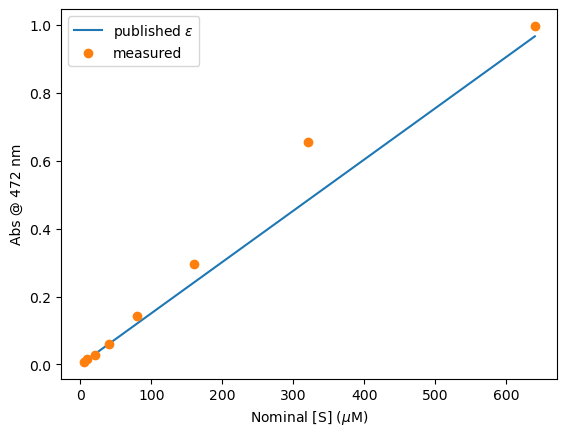

In [21]:
plt.figure()
plt.plot(nom_S_concs, np.array(nom_S_concs) * ex_472 / 10e6)
plt.plot(nom_S_concs, subs_abs[idx_472], 'o')
plt.xlabel('Nominal [S] ($\mu$M)')
plt.ylabel('Abs @ 472 nm')
plt.legend(['published $\epsilon$', 'measured'])
plt.show()

In [22]:
S_concs = subs_abs[idx_472] * (10e6 / ex_472)
print(S_concs)

[660.26490066 434.43708609 195.36423841  94.0397351   40.39735099
  17.8807947    9.93377483   5.29801325]


Now, perform an inner-filter calibration

In [23]:
edans_pt1 = load_calib('edans/210601_S+2_5uM_EDANS_and_S+5uM_EDANS_FRET.csv', cols=[0,11], blank=[5,5])
edans_pt2 = load_calib('edans/210601_S+10uM_EDANS_and_S+7_5uM_EDANS_FRET.csv', cols=[11,0], blank=[5,5])
subs = load_calib('edans/210601_substrate_FRET.csv', cols=[0])

edans = np.hstack([subs, edans_pt1, edans_pt2])
 
edans.shape, S_concs.shape

((8, 5), (8,))

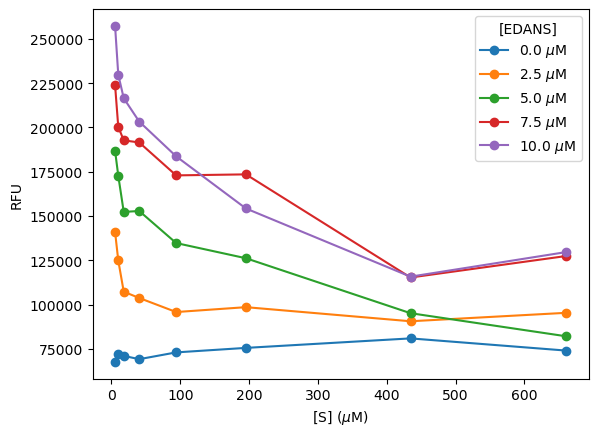

In [24]:
plt.figure()
plt.plot(S_concs, edans, '-o')
plt.xlabel('[S] ($\mu$M)')
plt.ylabel('RFU')
plt.legend(['%.1f $\mu$M'%p for p in P_concs], title='[EDANS]')
plt.show()

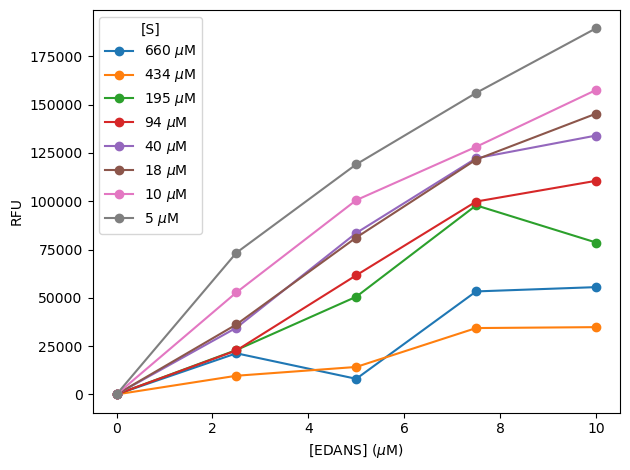

In [25]:
plt.figure()
plt.plot(P_concs, edans.T - edans.T[0,:][None,:], '-o')
plt.xlabel('[EDANS] ($\mu$M)')
plt.ylabel('RFU')
plt.legend(['%.0f $\mu$M'%s for s in S_concs], title='[S]')
plt.tight_layout()
plt.show()

In [26]:
S = np.outer(S_concs, np.ones(len(P_concs)))
P = np.outer( np.ones(len(S_concs)), P_concs)
X = edans[:,:]

print(S.shape, P.shape, X.shape)

(8, 5) (8, 5) (8, 5)


In [ ]:
# def pl_model(S, P, a, b, c, d, e):
#     """ returns f - powerlaw model """
#     return (a * np.power(S, b) + c)*P + S*d + e

# def pl_model(S, P, a, b, c, d, e):
#     """ returns f - Huyke model """
#     return (a * S + b * P) / np.exp(c * S) + e

# def pl_model(S, P, a, b, c, d, e):
#     """ returns f - Lakowicz model """
#     return c * P * np.exp(a*S) + e

# def pl_model(S, P, a, b, c, d, e):
#     """ returns f - modified Lakowicz model"""
#     return c * P * np.exp(a*(S**b)) + e

def pl_residual(params, S, P):
    r = X - pl_model(S, P, *params)
    return r.flatten()

#p0 = [-0.1, -0.1, 1.0, 0.0, 75000.0]
p0 = [0.1, 1.0, -0.1, 0.0, 75000.0]
popt, pcov = optimize.leastsq(pl_residual, p0, args=(S, P))

print(popt, pcov)

[-3.60998502e-21  1.65805337e-17 -7.15741509e-02  0.00000000e+00
  7.50000000e+04] 2


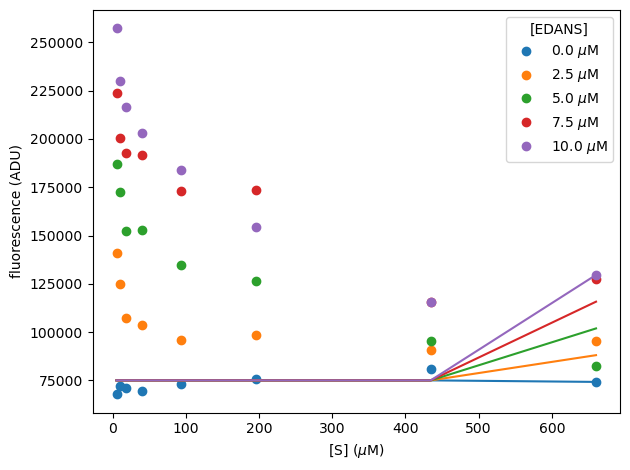

In [41]:
plt.figure()

plt.plot(S_concs, edans, 'o')

plt.gca().set_prop_cycle(None)
plt.plot(S_concs, pl_model(S, P, *popt))

plt.xlabel('[S] ($\mu$M)')
plt.ylabel('fluorescence (ADU)')

plt.legend(['%.1f $\mu$M'%p for p in P_concs], title='[EDANS]')

#plt.xscale('log')

plt.tight_layout()
plt.show()

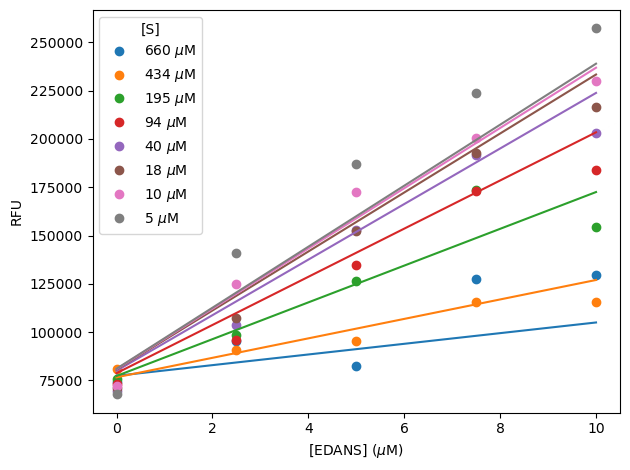

In [29]:
plt.figure()

plt.plot(P_concs, edans.T, 'o')

plt.gca().set_prop_cycle(None)
plt.plot(P_concs, pl_model(S, P, *popt).T)

plt.xlabel('[EDANS] ($\mu$M)')
plt.ylabel('RFU')
plt.legend(['%.0f $\mu$M'%s for s in S_concs], title='[S]')

plt.tight_layout()
plt.show()

Try again but fitting each EDANS series to an independent line

In [30]:
def indp_model(P, a, b):
    """ returns f """
    return a[:,None]*P + b[:,None]

def indp_residual(params, P):
    r = X - indp_model(P, params[:len(P)], params[len(P):])
    return r.flatten()


ip0 = np.ones(len(S_concs) * 2)
params_hat, pcov = optimize.leastsq(indp_residual, ip0, args=(P,))

a_opt = params_hat[:len(P)]
b_opt = params_hat[len(P):]
print(a_opt, b_opt)

[ 5725.60002903  3774.15002717  9289.1700424  11931.66002332
 14232.4        15043.98001048 15625.13998904 18475.97999878] [73154.24985483 80746.49986414 79218.09978799 72427.79980738
 72999.         72795.94995828 81882.70005695 82977.05001397]


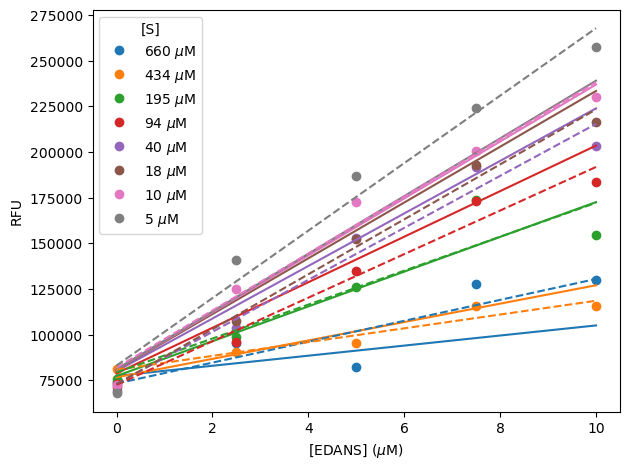

In [31]:
# PLOT BELOW:
# solid lines  = power law model
# dashed lines = linear model for each [S]

plt.figure()

plt.plot(P_concs, edans.T, 'o')

plt.gca().set_prop_cycle(None)
plt.plot(P_concs, pl_model(S, P, *popt).T)
plt.gca().set_prop_cycle(None)
plt.plot(P_concs, indp_model(P, a_opt, b_opt).T, '--')

plt.xlabel('[EDANS] ($\mu$M)')
plt.ylabel('RFU')
plt.legend(['%.0f $\mu$M'%s for s in S_concs], title='[S]')

plt.tight_layout()
plt.show()

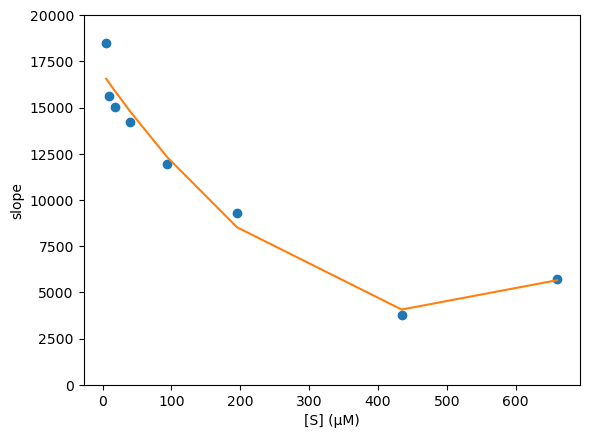

[ 5.51810115e-02 -5.33717996e+01  1.68392638e+04]


In [32]:
poly_coefs = np.polyfit(S_concs[:], a_opt[:], 2)

plt.figure()
plt.plot(S_concs, a_opt, "o")
plt.plot(S_concs, np.polyval(poly_coefs, S_concs))
plt.xlabel("[S] (µM)")
plt.ylabel("slope")
plt.ylim([0, 20000])
plt.show()

print(poly_coefs)